In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from src.shared.utils import fuzzy_match_dict
plt.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    #'text.usetex': True,
    'pgf.rcfonts': False,   # Fuente con serifa para coherencia con el texto
    "font.size": 11,          # Tamaño base
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.titlesize": 14,
    #"axes.titleweight": "bold",
    "grid.alpha": 0.1         # Rejilla más sutil
})

provincias_df = pd.read_csv('../data/processed/ine_ccaa_y_provincias.csv',sep=';',dtype=str)
provincia_cpro_dict = provincias_df.set_index('provincia')['cpro'].to_dict()
cpro_provincia_dict = provincias_df.set_index('cpro')['provincia'].to_dict()



# Conteo de universidades

In [11]:
universidades_df = pd.read_csv('../data/processed/universidades_arc_gis.csv',sep=';',dtype=str)
universidades_df['anno_publicacion'] = pd.to_datetime(universidades_df['fecha_publicacion'], errors='coerce').dt.year
universidades_df.rename(columns={'tipo':'Tipo'}, inplace=True)
pivot_universidades =universidades_df.query('anno_publicacion <= 2020').groupby(['cpro','Tipo']).size().sort_values(ascending=False).unstack(fill_value=0).apply(lambda x: x.map(lambda v: v if v > 0 else 0), axis=1)
pivot_universidades['Total'] = pivot_universidades.sum(axis=1)
copy = pivot_universidades.copy()
copy['cpro'] = copy.apply(lambda x: fuzzy_match_dict(x.name, provincia_cpro_dict), axis=1)
copy.to_csv('../data/golden/universidades_provincial.csv',sep=';')

# Conteo de parques científicos y tecnológicos por provincia, utilizando el dataset del RECIDI (Red Española de Centros de Innovación y Desarrollo Empresarial)

In [12]:

parques_df = pd.read_csv('../data/processed/parques_cientificos_tecnologicos_recidi.csv',sep=';')

In [13]:
parques_df['cpro'] = parques_df['provincia'].map(provincia_cpro_dict)
parques_df['cpro'].isna().sum()  # Verificar si hay provincias sin código asignado

np.int64(0)

In [14]:
parques_df.groupby('cpro').size().reset_index(name='parques').sort_values('parques',ascending=False).reset_index(drop=True).to_csv('../data/golden/parques_provincial.csv',sep=';')

In [15]:
conteo_parques =parques_df.groupby('cpro').size().reset_index(name='parques').sort_values('parques', ascending=False).reset_index(drop=True)
conteo_parques.rename(columns={'parques': 'Total Parques Científicos y Tecnológicos'}, inplace=True)

In [16]:
pivot_universidades

Tipo,Privada,Pública,Total
cpro,,,
03,0,2,2
04,0,1,1
05,1,0,1
06,0,1,1
07,0,1,1
08,5,3,8
09,1,1,2
11,0,1,1
12,0,1,1


In [17]:

pivot_universidades.rename(columns={'Privada':'Universidad Privada', 'Pública':'Universidad Pública', 'Total':'Total Universidades'}, inplace=True)
unis_parques = pivot_universidades.merge(conteo_parques, left_on='cpro', right_on='cpro', how='left').fillna(0).copy()
unis_parques['provincia'] = unis_parques['cpro'].map(cpro_provincia_dict)
unis_parques['Total Universidades y Parques'] = unis_parques['Total Universidades'] + unis_parques['Total Parques Científicos y Tecnológicos']
unis_parques.sort_values('Total Universidades y Parques', ascending=False)

,cpro,Universidad Privada,Universidad Pública,Total Universidades,Total Parques Científicos y Tecnológicos,provincia,Total Universidades y Parques
19,28,12,8,20,7.0,Madrid,27.0
5,08,5,3,8,7.0,Barcelona,15.0
31,46,4,1,5,3.0,Valencia/València,8.0
23,35,3,1,4,3.0,"Palmas, Las",7.0
29,41,1,2,3,3.0,Sevilla,6.0
0,03,0,2,2,2.0,Alicante/Alacant,4.0
13,20,1,0,1,3.0,Gipuzkoa,4.0
27,39,1,1,2,2.0,Cantabria,4.0
26,38,1,1,2,1.0,Santa Cruz de Tenerife,3.0
21,30,1,1,2,1.0,Murcia,3.0


# Clusteres de innovación

In [22]:
clusteres_df = pd.read_csv('../data/processed/agrupaciones_empresariales_innovadoras.csv',sep=';',dtype=str)

In [23]:
from src.shared.utils import fuzzy_match_dict


clusteres_df['cpro'] = clusteres_df['provincia'].map(lambda x: fuzzy_match_dict(x, provincia_cpro_dict))
clusteres_df['Provincia'] = clusteres_df['cpro'].map(cpro_provincia_dict)
clusteres_df.value_counts('sector')


sector
TIC                                    16
Medioambiente y Energía                16
Agroalimentario                        14
Biotecnología y Salud                  11
Automoción                             10
Materiales                              9
Maquinaria y Tecnología Industrial      8
Logística                               6
Hábitat                                 6
Textil y calzado                        5
Media                                   5
Naval                                   4
Aeronáutico                             3
Turismo                                 3
Deporte                                 2
Infancia y Juguete                      1
Ferroviario                             1
Name: count, dtype: int64

In [24]:
clusteres_df.rename(columns={'sector':'Sector'}, inplace=True)
pivot_aei =clusteres_df.groupby(['Provincia','Sector']).size().sort_values(ascending=False).unstack(fill_value=0).apply(lambda x: x.map(lambda v: v if v > 0 else 0), axis=1)
pivot_aei['Total'] = pivot_aei.sum(axis=1)
clusteres_df.groupby(['cpro','Sector']).size().sort_values(ascending=False).unstack(fill_value=0).apply(lambda x: x.map(lambda v: v if v > 0 else 0), axis=1).to_csv('../data/golden/aei_provincial.csv',sep=';')

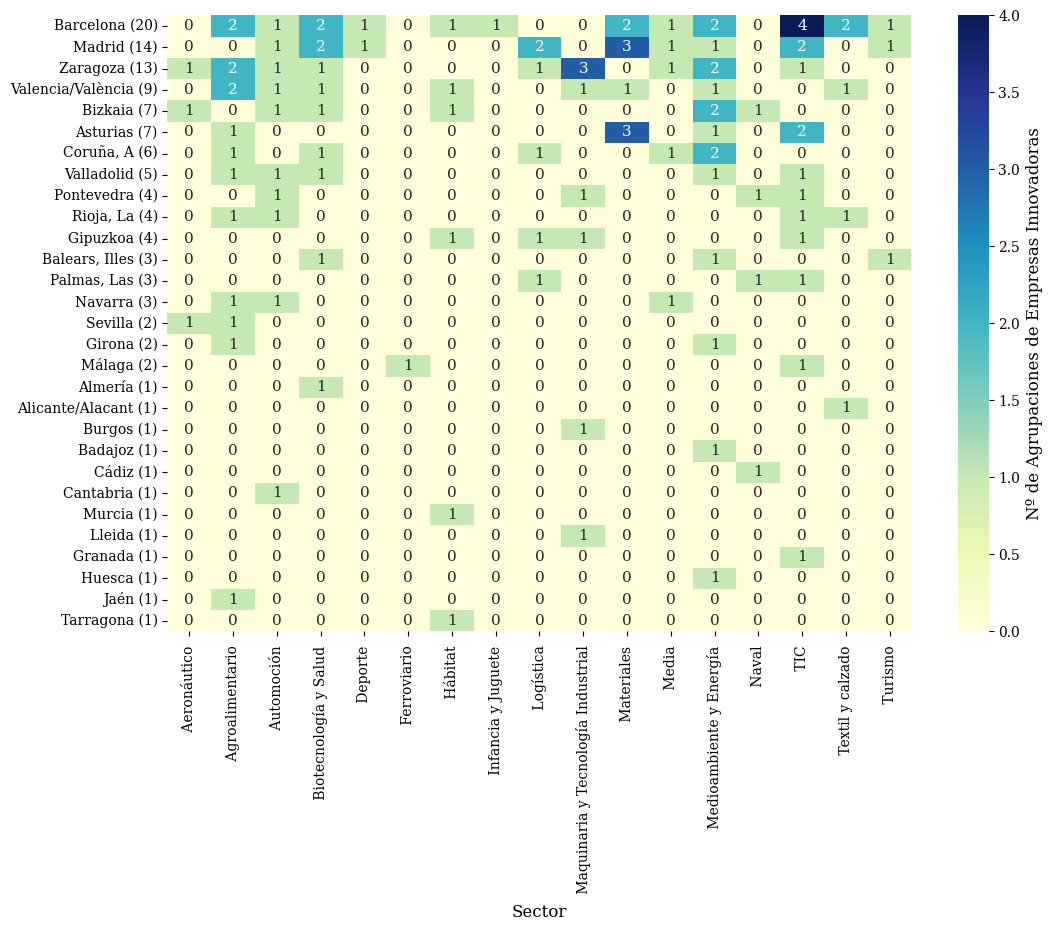

In [166]:

plt.figure(figsize=(12, 8))
pivot_aei = pivot_aei.sort_values('Total', ascending=False)
provincias_labels = [f"{prov} ({total})" for prov, total in zip(pivot_aei.index, pivot_aei['Total'])]
pivot_aei.index = provincias_labels
sns.heatmap(pivot_aei[pivot_aei.columns[:-1]], annot=True, cmap="YlGnBu", cbar_kws={'label': 'Nº de Agrupaciones de Empresas Innovadoras'})
#plt.title('Concentración de Clústeres de Innovación por Provincia y Sector')
plt.savefig('../docs/manuscrito/recursos/figuras/aei-provincia.pdf', format='pdf', bbox_inches='tight', pad_inches=0.1)
plt.show()

# Centros tecnologicos y de apoyo a la innovación

In [9]:
import pandas as pd
ct_y_cait_df = pd.read_csv('../data/processed/centros_tecnologicos_y_de_apoyo_recidi.csv',sep=';',dtype=str)

In [10]:
ct_y_cait_df.query('modalidad == "Centro de Apoyo a la Innovación Tecnológica"')[['denominacion_del_centro','provincia']].reset_index(drop=True).to_json(orient='records')

'[{"denominacion_del_centro":"FUNDACIO PRIVADA I2CAT INTERNET I INNOVACIO DIGITAL A CATALUNYA","provincia":"BARCELONA"},{"denominacion_del_centro":"FUNDACION I D DEL SOFTWARE LIBRE","provincia":"GRANADA"},{"denominacion_del_centro":"FOMENTO DE LAS ARTES Y DEL DISE\\u00d1O (FAD)","provincia":"BARCELONA"},{"denominacion_del_centro":"ASOC. DE INVESTIGACION Y COOPERACION INDUSTRIAL ANDALUCIA F. DE PAULA R.","provincia":"SEVILLA"},{"denominacion_del_centro":"ISEA, S. COOP.","provincia":"GUIPUZCOA"},{"denominacion_del_centro":"FUNDACION CITOLIVA, CENTRO DE INNOVACION Y TECNOLOGIA DEL OLIVAR Y DEL ACEITE","provincia":"JAEN"},{"denominacion_del_centro":"FUNDACION CENTRO GALLEGO DE INVESTIGACIONES DEL AGUA","provincia":"A CORU\\u00d1A"},{"denominacion_del_centro":"CETAQUA, CENTRO TECNOLOGICO DEL AGUA, FUNDACION PRIVADA","provincia":"BARCELONA"},{"denominacion_del_centro":"CS CENTRO STIRLING S.COOP.","provincia":"GUIPUZCOA"},{"denominacion_del_centro":"ASOC EMPRESARIAL DE INVESTIGACION CENTRO TE

In [11]:
ct_y_cait_df['cpro'] = ct_y_cait_df['cp'].str[:2]
ct_y_cait_df['Provincia'] = ct_y_cait_df['cpro'].map(cpro_provincia_dict)
pivot_ct_cait = ct_y_cait_df.groupby(['Provincia','modalidad']).size().sort_values(ascending=False).unstack(fill_value=0).apply(lambda x: x.map(lambda v: v if v > 0 else 0), axis=1)
pivot_ct_cait['Total'] = pivot_ct_cait.sum(axis=1)
pivot_ct_cait = pivot_ct_cait.sort_values('Total', ascending=False)
_ct_cait = ct_y_cait_df.groupby(['cpro','modalidad']).size().sort_values(ascending=False).unstack(fill_value=0).apply(lambda x: x.map(lambda v: v if v > 0 else 0), axis=1)
_ct_cait.to_csv('../data/golden/ct_cait_provincial.csv',sep=';')

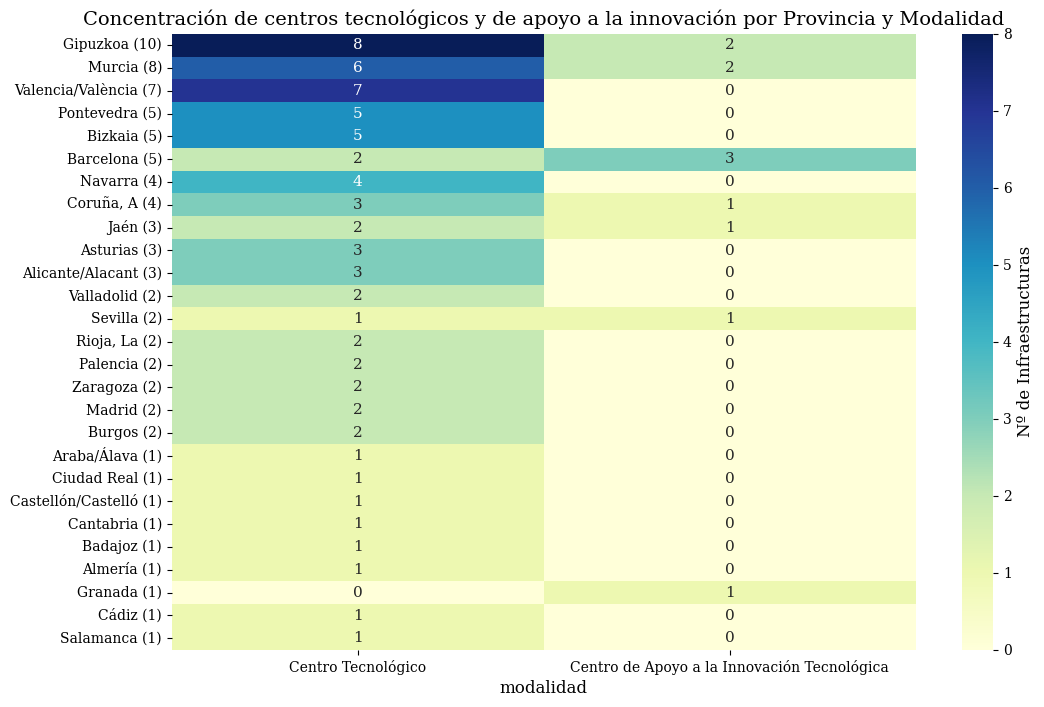

In [13]:
plt.figure(figsize=(12, 8))
pivot_ct_cait = pivot_ct_cait.sort_values('Total', ascending=False)
provincias_labels = [f"{prov} ({total})" for prov, total in zip(pivot_ct_cait.index, pivot_ct_cait['Total'])]
pivot_ct_cait.index = provincias_labels
sns.heatmap(pivot_ct_cait[pivot_ct_cait.columns[:-1]], annot=True, cmap="YlGnBu", cbar_kws={'label': 'Nº de Infraestructuras'})
plt.title('Concentración de centros tecnológicos y de apoyo a la innovación por Provincia y Modalidad')
plt.show()

# ICTS

In [7]:
icts_df = pd.read_csv('../data/processed/icts.csv',sep=';',dtype=str)
icts_df['codigo_postal'] = icts_df['direccion'].str.extract(r'(\d{5})')
icts_df['cpro'] = icts_df['codigo_postal'].str[:2]
icts_df['Provincia'] = icts_df['cpro'].map(cpro_provincia_dict)
icts_df.rename(columns={'area_tematica':'Área Temática'}, inplace=True)
pivot_icts =icts_df.groupby(['Provincia','Área Temática']).size().sort_values(ascending=False).unstack(fill_value=0).apply(lambda x: x.map(lambda v: v if v > 0 else 0), axis=1)
pivot_icts['Total'] = pivot_icts.sum(axis=1)
pivot_icts =icts_df.groupby(['cpro','Área Temática']).size().sort_values(ascending=False).unstack(fill_value=0).apply(lambda x: x.map(lambda v: v if v > 0 else 0), axis=1).to_csv('../data/golden/icts_provincial.csv',sep=';')

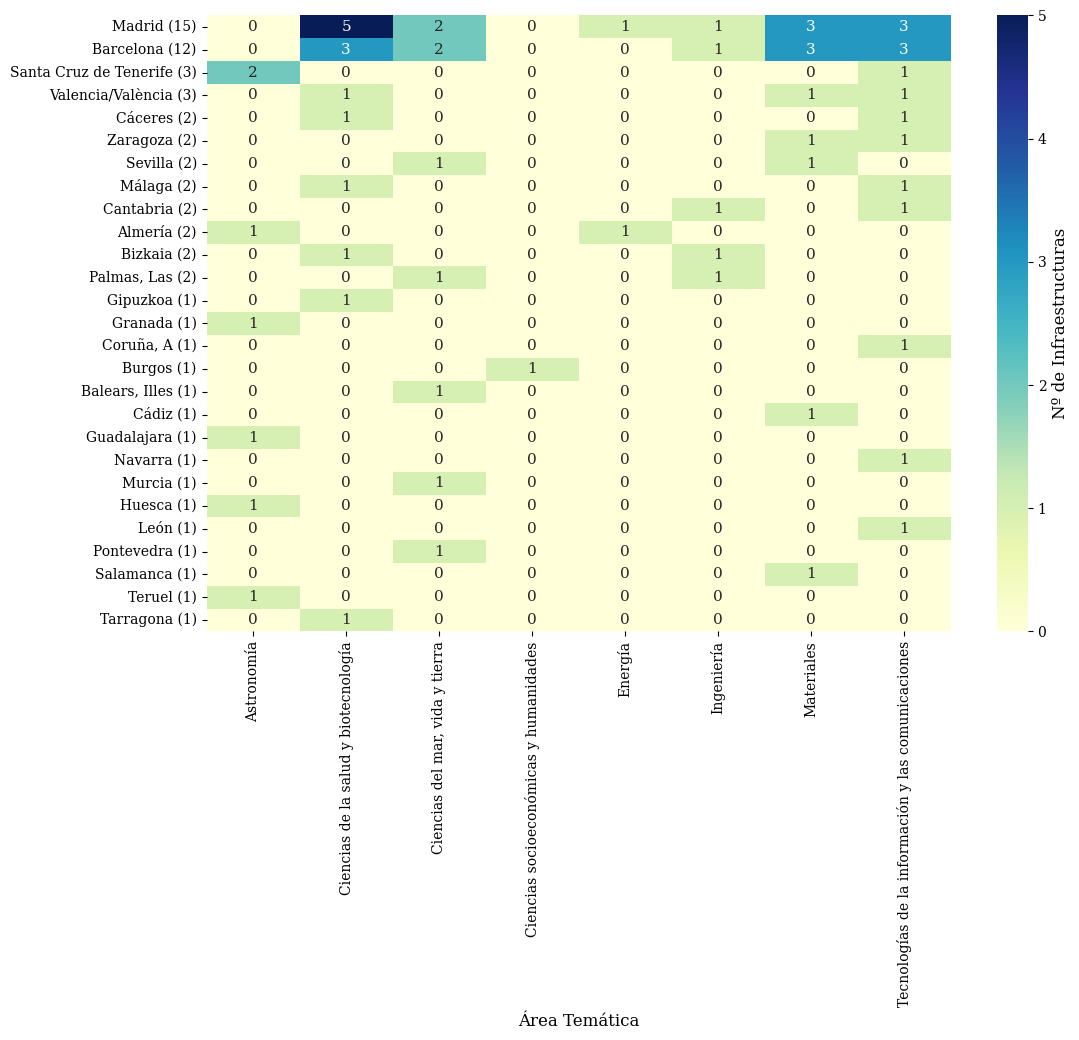

In [14]:
plt.figure(figsize=(12, 8))
pivot_icts = pivot_icts.sort_values('Total', ascending=False)
provincias_labels = [f"{prov} ({total})" for prov, total in zip(pivot_icts.index, pivot_icts['Total'])]
pivot_icts.index = provincias_labels
sns.heatmap(pivot_icts[pivot_icts.columns[:-1]], annot=True, cmap="YlGnBu", cbar_kws={'label': 'Nº de Infraestructuras'})
#plt.title('Concentración de Infraestructuras Científicas y Técnicas Singulares por Provincia y Sector')
plt.savefig('../docs/manuscrito/recursos/figuras/icts-provincia.pdf', format='pdf', bbox_inches='tight', pad_inches=0.1)
plt.show()

# Centros y unidades de Excelencia

In [15]:
from src.shared.utils import fuzzy_match_dict
centros_somma_df = pd.read_csv('../data/processed/centros_somma_recidi.csv',sep=';',dtype=str)
centros_somma_df['cpro'] = centros_somma_df['provincia'].map(lambda x: fuzzy_match_dict(x, provincia_cpro_dict))
centros_somma_df['cpro'].isna().sum()

np.int64(0)

In [16]:
pivot_centros_somma = centros_somma_df.groupby(['provincia','sector']).size().sort_values(ascending=False).unstack(fill_value=0).apply(lambda x: x.map(lambda v: v if v > 0 else 0), axis=1)
pivot_centros_somma['Total'] = pivot_centros_somma.sum(axis=1)
centros_somma_df.groupby(['cpro','sector']).size().sort_values(ascending=False).unstack(fill_value=0).apply(lambda x: x.map(lambda v: v if v > 0 else 0), axis=1).to_csv('../data/golden/centros_somma_provincial.csv',sep=';')

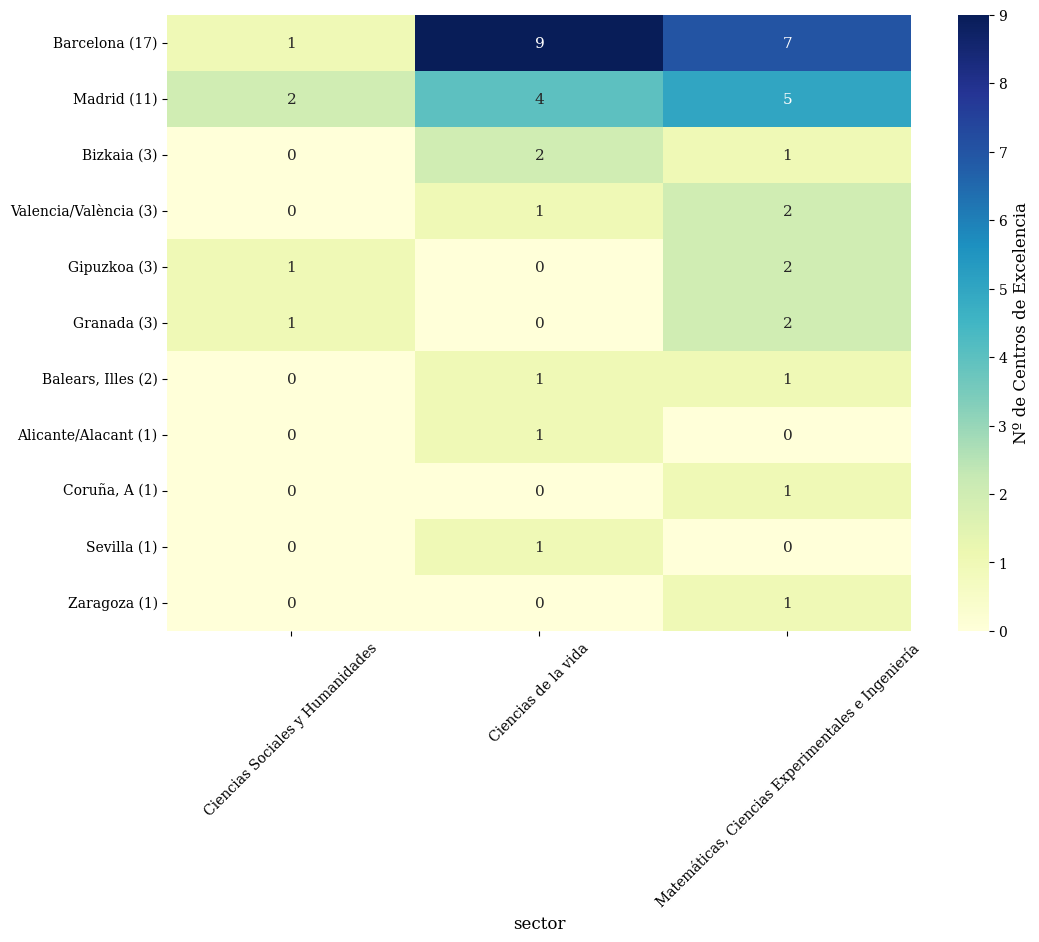

In [26]:
plt.figure(figsize=(12, 8))
pivot_centros_somma = pivot_centros_somma.sort_values('Total', ascending=False)
provincias_labels = [f"{prov} ({total})" for prov, total in zip(pivot_centros_somma.index, pivot_centros_somma['Total'])]
pivot_centros_somma.index = provincias_labels
sns.heatmap(pivot_centros_somma[pivot_centros_somma.columns[:-1]], annot=True, cmap="YlGnBu", cbar_kws={'label': 'Nº de Centros de Excelencia'})
plt.xticks(rotation=45, ha='center')
#plt.title('Concentración de Centros de Excelencia Severo Ochoa y María de Maetzu por Provincia y Sector')
plt.savefig('../docs/manuscrito/recursos/figuras/centros-somma-provincia.pdf', format='pdf', bbox_inches='tight', pad_inches=0.1)
plt.show()